In [2]:
# If needed once in this environment:
# %pip install python-dotenv sqlalchemy pyodbc pandas numpy scikit-learn lifelines

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from lifelines import CoxPHFitter
except ImportError:
    CoxPHFitter = None

sys.path.insert(0, '..')

from util.db import create_db_engine
from util.sql_loader import read_sql_file
from util.sql_runner import execute_sql_and_read_temp_table
from util.xpd_features import build_xpd_features_v6, build_loan_level_payin_v6

In [3]:
# Paths
project_root = Path.cwd().resolve().parent  # .../yieldCurve_augmenting
env_path = project_root / '.env'
v3_sql_path = project_root / 'sql_scripts' / 'jcx_raw_harvey_v3.sql'
v6_sql_path = project_root / 'sql_scripts' / 'jcx_raw_harvey_v6.sql'

# Load SQL and execute temp-table workflows (v3 payment grain + v6 installment grain).
engine = create_db_engine(env_path)

setup_sql_v3 = read_sql_file(v3_sql_path)
raw_df = execute_sql_and_read_temp_table(engine, setup_sql_v3, '#t7')

setup_sql_v6 = read_sql_file(v6_sql_path)
raw_v6_df = execute_sql_and_read_temp_table(engine, setup_sql_v6, '#t17_final')

print('Using env file:', env_path)
print('v3 SQL loaded from:', v3_sql_path)
print('v6 SQL loaded from:', v6_sql_path)
print('raw_df (v3) shape:', raw_df.shape)
print('raw_v6_df shape:', raw_v6_df.shape)
print('v3 unique loans:', raw_df['LoanID'].nunique())
print('v6 unique loans:', raw_v6_df['LoanID'].nunique())
raw_df.head()

Using env file: /Users/starsrain/2025_concord/yieldCurve_augmenting/.env
v3 SQL loaded from: /Users/starsrain/2025_concord/yieldCurve_augmenting/sql_scripts/jcx_raw_harvey_v3.sql
v6 SQL loaded from: /Users/starsrain/2025_concord/yieldCurve_augmenting/sql_scripts/jcx_raw_harvey_v6.sql
raw_df (v3) shape: (4626704, 29)
raw_v6_df shape: (862855, 29)
v3 unique loans: 195777
v6 unique loans: 195784


,LoanID,OriginatedAmount,AppYear,AppMonth,AppWeek,InstallmentNumber,CollectedPaymentAmount,PaymentType,Payment_Number,PaymentStatus,...,OriginationDate,numOfReturn,numOfPayment,PaymentDate,PmtYear,PmtMonth,PmtWeek,InstallStatusCode,InstallmentStatus,InstallDueDate
0,I1529858-0,900.0,2023,1,1,1,450.0,Installment Pmt,1,D,...,2023-01-03,5,21,2023-01-25,2023,1,4,111,Paid Off,2023-01-25
1,I1529858-0,900.0,2023,1,1,2,0.0,Installment Pmt,2,R,...,2023-01-03,5,21,2023-02-22,2023,2,8,825,Closed for Arrangements,2023-02-22
2,I1529858-0,900.0,2023,1,1,2,0.0,Installment Pmt,3,R,...,2023-01-03,5,21,2023-02-24,2023,2,8,825,Closed for Arrangements,2023-02-22
3,I1529858-0,900.0,2023,1,1,2,0.0,Installment Pmt,4,R,...,2023-01-03,5,21,2023-02-27,2023,2,9,825,Closed for Arrangements,2023-02-22
4,I1529858-0,900.0,2023,1,1,2,0.0,W,5,R,...,2023-01-03,5,21,2023-02-27,2023,2,9,825,Closed for Arrangements,2023-02-22


## V6 Loan-Level Feature Assembly

In [4]:
xpd_features_df = build_xpd_features_v6(raw_v6_df)
loan_payin_df = build_loan_level_payin_v6(raw_v6_df)

print('xpd_features_df shape:', xpd_features_df.shape)
print('loan_payin_df shape:', loan_payin_df.shape)

v3_loans = set(raw_df['LoanID'].dropna().unique())
v6_loans = set(raw_v6_df['LoanID'].dropna().unique())
common_loans = len(v3_loans.intersection(v6_loans))
print('loan overlap v3 vs v6:', common_loans)

loan_payin_df[['LoanID', 'TotalRealizedPayin_canonical', 'payin_ratio_canonical', 'payin_ratio_gap']].head()

xpd_features_df shape: (195784, 7)
loan_payin_df shape: (195784, 9)
loan overlap v3 vs v6: 195777


,LoanID,TotalRealizedPayin_canonical,payin_ratio_canonical,payin_ratio_gap
0,I1529359-0,2109.68,1.406453,0.0
1,I1529362-0,763.57,1.272617,0.0
2,I1529363-0,358.50,1.195000,0.0
3,I1529364-0,700.00,1.400000,0.0
4,I1529365-0,2461.00,1.640667,0.0


## V3-V6 Reconciliation Checks

In [5]:
v3_loan_count = raw_df['LoanID'].nunique()
v6_loan_count = raw_v6_df['LoanID'].nunique()

v3_loans = set(raw_df['LoanID'].dropna().unique())
v6_loans = set(raw_v6_df['LoanID'].dropna().unique())

coverage_df = pd.DataFrame([
    {
        'v3_unique_loans': v3_loan_count,
        'v6_unique_loans': v6_loan_count,
        'loan_overlap_count': len(v3_loans.intersection(v6_loans)),
        'v3_only_loans': len(v3_loans - v6_loans),
        'v6_only_loans': len(v6_loans - v3_loans),
        'sum_canonical_payin': float(loan_payin_df['TotalRealizedPayin_canonical'].sum()),
        'sum_install_payin': float(loan_payin_df['TotalRealizedPayin_from_install'].sum()),
        'sum_payin_gap': float((loan_payin_df['TotalRealizedPayin_from_install'] - loan_payin_df['TotalRealizedPayin_canonical']).sum()),
    }
])

coverage_df

,v3_unique_loans,v6_unique_loans,loan_overlap_count,v3_only_loans,v6_only_loans,sum_canonical_payin,sum_install_payin,sum_payin_gap
0,195777,195784,195777,0,7,2.390266e+08,2.216199e+08,-17406682.77


## V1 Configuration

In [6]:
## Data Contract And QC
# Stage A terminal loan-status event set:
# C=Charge Off, B=Bankruptcy, T=Closed For 3rd Party, A=Account Settled,
# D=Loan Paid Off, L=Debt Collection Agency, R=Returned Item.
terminal_statuses = {'C', 'B', 'T', 'A', 'D', 'L', 'R'}

# Stage C delinquent-recovery pool (exclude paid-off D by design).
# R=Returned Item, T=Closed For 3rd Party, L=Debt Collection Agency.
delinquent_loan_statuses = {'R', 'T', 'L'}

max_k = 20
min_portfolio_loans = 120
ridge_alpha = 1.0

# Segmentation config: start with NEW-only modeling.
new_customers_only = True
new_cust_value = 'NEW'

# Stage C placeholder recovery rates by days-late bins.
stage_c_rate_map = {
    (1, 30): 0.40,
    (31, 60): 0.25,
    (61, 90): 0.15,
    (91, 9999): 0.08,
}

# Holdout is most recent 20% of originations.
cutoff_date = None

In [8]:
required_cols = [
    'LoanID', 'OriginatedAmount', 'InstallmentNumber', 'CollectedPaymentAmount',
    'PaymentStatus', 'PaymentType', 'PaymentDate', 'InstallDueDate',
    'OriginationDate', 'PortFolioID', 'CustType', 'Frequency', 'LoanStatus',
    'numOfReturn', 'numOfPayment', 'AppMonth'
]

missing_cols = [c for c in required_cols if c not in raw_df.columns]
if missing_cols:
    raise ValueError(f'Missing required #t7 columns: {missing_cols}')

for date_col in ['PaymentDate', 'InstallDueDate', 'OriginationDate']:
    raw_df[date_col] = pd.to_datetime(raw_df[date_col], errors='coerce')

numeric_cols = [
    'OriginatedAmount', 'InstallmentNumber', 'CollectedPaymentAmount',
    'numOfReturn', 'numOfPayment', 'AppMonth', 'PortFolioID'
]
for ncol in numeric_cols:
    raw_df[ncol] = pd.to_numeric(raw_df[ncol], errors='coerce')

print('rows:', len(raw_df))
print('unique loans:', raw_df['LoanID'].nunique())
print('payment date min/max:', raw_df['PaymentDate'].min(), raw_df['PaymentDate'].max())
print('origination min/max:', raw_df['OriginationDate'].min(), raw_df['OriginationDate'].max())
print('\nnull rate (required cols):')
print((raw_df[required_cols].isna().mean().sort_values(ascending=False) * 100).round(2))

print('\nLeakage guardrails used in V1:')
print('- Stage B uses only lagged behavioral features (k-1 history).')
print('- numOfPayment is NOT used as a model feature.')
print('- Stage C loans are excluded from A x B combine output.')

rows: 4626704
unique loans: 195777
payment date min/max: 2023-01-01 00:00:00 2028-03-10 00:00:00
origination min/max: 2023-01-01 00:00:00 2026-04-01 00:00:00

null rate (required cols):
OriginationDate           0.03
Frequency                 0.00
PaymentDate               0.00
LoanID                    0.00
OriginatedAmount          0.00
InstallmentNumber         0.00
CollectedPaymentAmount    0.00
PaymentStatus             0.00
PaymentType               0.00
InstallDueDate            0.00
PortFolioID               0.00
CustType                  0.00
LoanStatus                0.00
numOfReturn               0.00
numOfPayment              0.00
AppMonth                  0.00
dtype: float64

Leakage guardrails used in V1:
- Stage B uses only lagged behavioral features (k-1 history).
- numOfPayment is NOT used as a model feature.
- Stage C loans are excluded from A x B combine output.


## Build Modeling Bases

In [9]:
if new_customers_only:
    raw_df_model = raw_df[raw_df['CustType'].astype(str).str.upper() == new_cust_value].copy()
else:
    raw_df_model = raw_df.copy()

raw_df_model = raw_df_model.sort_values(['LoanID', 'PaymentDate', 'PaymentID']).copy()

print('model scope:', 'NEW only' if new_customers_only else 'ALL customers')
print('rows before filter:', len(raw_df), '| after filter:', len(raw_df_model))
print('loans before filter:', raw_df['LoanID'].nunique(), '| after filter:', raw_df_model['LoanID'].nunique())

if raw_df_model.empty:
    raise ValueError('NEW-only filter returned zero rows. Check CustType values and new_cust_value config.')

# Loan-level base (one row per loan).
loan_base = (
    raw_df_model.groupby('LoanID', as_index=False)
    .agg(
        PortFolioID=('PortFolioID', 'first'),
        OriginatedAmount=('OriginatedAmount', 'first'),
        # v3 payment-grain source no longer carries loan-level total directly.
        TotalRealizedPayin=('CollectedPaymentAmount', 'sum'),
        OriginationDate=('OriginationDate', 'first'),
        LoanStatus=('LoanStatus', 'last'),
        CustType=('CustType', 'first'),
        Frequency=('Frequency', 'first'),
        numOfReturn=('numOfReturn', 'first'),
        AppMonth=('AppMonth', 'first'),
        duration=('InstallmentNumber', 'max')
    )
)

# Merge v6 loan-level enrichments once (xPD + canonical payin).
loan_base = loan_base.merge(xpd_features_df, on='LoanID', how='left')
loan_base = loan_base.merge(
    loan_payin_df[
        [
            'LoanID',
            'TotalRealizedPayin_canonical',
            'payin_ratio_canonical',
            'payin_ratio_gap',
            'TotalRealizedPayin_from_install',
        ]
    ],
    on='LoanID',
    how='left',
)

xpd_cols = ['fpd_flag', 'spd_flag', 'tpd_flag', 'xpd_count', 'earliest_default_inst', 'payoff_by_inst_5']
for c in xpd_cols:
    loan_base[c] = pd.to_numeric(loan_base[c], errors='coerce').fillna(0).astype(int)

# Canonical payin target comes from v6 loan-level SQL total.
loan_base['TotalRealizedPayin'] = loan_base['TotalRealizedPayin_canonical'].fillna(loan_base['TotalRealizedPayin'])
loan_base['payin_ratio'] = loan_base['payin_ratio_canonical'].fillna(
    loan_base['TotalRealizedPayin'] / loan_base['OriginatedAmount'].replace(0, np.nan)
)
loan_base['payin_ratio'] = loan_base['payin_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)

loan_base['event'] = loan_base['LoanStatus'].isin(terminal_statuses).astype(int)

# Feature encoding for Stage A.
loan_base['Frequency_enc'] = loan_base['Frequency'].astype('category').cat.codes
loan_base['CustType_bin'] = (loan_base['CustType'].astype(str).str.upper() == 'RETURN').astype(int)
loan_base['log_orig_amt'] = np.log1p(loan_base['OriginatedAmount'].clip(lower=0))
loan_base['month_sin'] = np.sin(2 * np.pi * loan_base['AppMonth'].fillna(1) / 12.0)
loan_base['month_cos'] = np.cos(2 * np.pi * loan_base['AppMonth'].fillna(1) / 12.0)

# Time split cutoff (most recent 20% of originations is holdout).
cutoff_date = loan_base['OriginationDate'].dropna().quantile(0.80)
loan_base['is_holdout'] = loan_base['OriginationDate'] >= cutoff_date

if loan_base['LoanID'].nunique() < min_portfolio_loans:
    raise ValueError('Insufficient NEW-customer loans after filter. Lower thresholds or broaden segment.')

# Installment-level sequence base.
seq_base = (
    raw_df_model.groupby(['LoanID', 'InstallmentNumber'], as_index=False)
    .agg(
        PortFolioID=('PortFolioID', 'first'),
        OriginatedAmount=('OriginatedAmount', 'first'),
        OriginationDate=('OriginationDate', 'first'),
        InstallDueDate=('InstallDueDate', 'max'),
        PaymentDate=('PaymentDate', 'max'),
        PaymentStatus=('PaymentStatus', 'last'),
        PaymentType=('PaymentType', 'last'),
        LoanStatus=('LoanStatus', 'last'),
        Frequency=('Frequency', 'first'),
        CustType=('CustType', 'first'),
        numOfReturn=('numOfReturn', 'first'),
        AppMonth=('AppMonth', 'first'),
        PaidOffPaymentAmount=('CollectedPaymentAmount', 'sum')
    )
)

seq_base['is_realized_cash'] = (seq_base['PaymentStatus'] == 'D').astype(int)
seq_base['step_paid'] = np.where(seq_base['is_realized_cash'] == 1, seq_base['PaidOffPaymentAmount'], 0.0)
seq_base['step_payin_ratio'] = (
    seq_base['step_paid'] / seq_base['OriginatedAmount'].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan).fillna(0.0)
seq_base['step_payin_ratio_fit'] = seq_base['step_payin_ratio']

seq_base['days_late'] = (seq_base['PaymentDate'] - seq_base['InstallDueDate']).dt.days
seq_base['days_late'] = seq_base['days_late'].fillna(0).clip(lower=0)

# Static encodings reused in Stage B.
seq_base['Frequency_enc'] = seq_base['Frequency'].astype('category').cat.codes
seq_base['CustType_bin'] = (seq_base['CustType'].astype(str).str.upper() == 'RETURN').astype(int)
seq_base['log_orig_amt'] = np.log1p(seq_base['OriginatedAmount'].clip(lower=0))
seq_base['month_sin'] = np.sin(2 * np.pi * seq_base['AppMonth'].fillna(1) / 12.0)
seq_base['month_cos'] = np.cos(2 * np.pi * seq_base['AppMonth'].fillna(1) / 12.0)

seq_base['has_early'] = (seq_base['PaymentType'] == 'Early Pmt').astype(int)
seq_base['has_arrangement'] = (seq_base['PaymentType'] == 'Arr Pmt').astype(int)
seq_base['has_reset'] = (seq_base['PaymentType'] == 'Reset Pmt').astype(int)
seq_base['is_return'] = (seq_base['PaymentStatus'] == 'R').astype(int)
seq_base['is_partial'] = (seq_base['PaymentType'] == 'Partial Pmt').astype(int)
seq_base['is_void'] = (seq_base['PaymentStatus'] == 'V').astype(int)
seq_base['is_3rdparty'] = (seq_base['PaymentType'] == '3rd Party Pmt').astype(int)

seq_base = seq_base.sort_values(['LoanID', 'InstallmentNumber']).copy()
for src, out in [
    ('is_return', 'cum_return_rate_lag'),
    ('is_partial', 'cum_partial_rate_lag'),
    ('is_void', 'cum_void_rate_lag'),
    ('is_3rdparty', 'cum_3rdparty_rate_lag'),
    ('step_payin_ratio', 'cum_payin_ratio_lag'),
]:
    seq_base[out] = (
        seq_base.groupby('LoanID')[src]
        .transform(lambda x: x.shift(1).expanding().mean())
        .fillna(0.0)
    )

# Approximation for default rate in V1 (using return status proxy).
seq_base['cum_default_rate_lag'] = seq_base['cum_return_rate_lag']

seq_base = seq_base.merge(
    loan_base[['LoanID', 'is_holdout']],
    on='LoanID',
    how='left'
)

# Latest loan snapshot used for Stage C.
latest_loan_snapshot = (
    seq_base.sort_values(['LoanID', 'InstallmentNumber'])
    .groupby('LoanID', as_index=False)
    .tail(1)
)

delinquent_base = latest_loan_snapshot[
    latest_loan_snapshot['LoanStatus'].isin(delinquent_loan_statuses)
].copy()

delinquent_base['realized_to_date'] = delinquent_base['LoanID'].map(
    loan_base.set_index('LoanID')['TotalRealizedPayin']
).fillna(0.0)
delinquent_base['remaining_balance'] = (
    delinquent_base['OriginatedAmount'] - delinquent_base['realized_to_date']
).clip(lower=0.0)

# Extra guardrail: Stage C should only keep loans with outstanding balance.
delinquent_base = delinquent_base[delinquent_base['remaining_balance'] > 0].copy()

portfolio_counts = loan_base['PortFolioID'].value_counts().sort_index()
xpd_null_rate = loan_base[xpd_cols].isna().mean().mean() if xpd_cols else 0.0
canonical_missing = loan_base['TotalRealizedPayin_canonical'].isna().mean()

print('cutoff_date:', cutoff_date)
print('loan_base shape:', loan_base.shape)
print('seq_base shape:', seq_base.shape)
print('delinquent_base shape:', delinquent_base.shape)
print('portfolio loan counts:\n', portfolio_counts)
print('xPD mean null rate:', round(float(xpd_null_rate), 6))
print('canonical payin missing rate:', round(float(canonical_missing), 6))
print('aggregate payin ratio gap (install - canonical):', round(float(loan_payin_df['payin_ratio_gap'].sum()), 6))

if portfolio_counts.empty:
    raise ValueError('No portfolios available after NEW-only filtering.')

loan_base.head()

model scope: NEW only
rows before filter: 4626704 | after filter: 2148127
loans before filter: 195777 | after filter: 88000
cutoff_date: 2025-05-28 00:00:00
loan_base shape: (88000, 29)
seq_base shape: (1312781, 39)
delinquent_base shape: (3577, 41)
portfolio loan counts:
 PortFolioID
1    21311
5    23737
6    21784
7    21168
Name: count, dtype: int64
xPD mean null rate: 0.0
canonical payin missing rate: 0.126466
aggregate payin ratio gap (install - canonical): -28471.013949


,LoanID,PortFolioID,OriginatedAmount,TotalRealizedPayin,OriginationDate,LoanStatus,CustType,Frequency,numOfReturn,AppMonth,...,payin_ratio_gap,TotalRealizedPayin_from_install,payin_ratio,event,Frequency_enc,CustType_bin,log_orig_amt,month_sin,month_cos,is_holdout
0,I1529369-0,1,1000.0,2157.16,2023-01-03,A,NEW,M,2,1,...,-0.50,1657.16,2.157160,1,1,0,6.908755,0.5,0.866025,False
1,I1529371-0,1,800.0,1696.00,2023-01-03,C,NEW,S,9,1,...,0.00,1696.00,2.120000,1,2,0,6.685861,0.5,0.866025,False
2,I1529394-0,7,800.0,1140.38,2023-01-03,D,NEW,M,0,1,...,0.00,1140.38,1.425475,1,1,0,6.685861,0.5,0.866025,False
3,I1529423-0,5,900.0,1980.00,2023-01-03,D,NEW,B,0,1,...,0.00,1980.00,2.200000,1,0,0,6.803505,0.5,0.866025,False
4,I1529424-0,5,800.0,740.00,2023-01-02,C,NEW,W,8,1,...,-0.32,484.00,0.925000,1,3,0,6.685861,0.5,0.866025,False


## Stage A: Cox Survival By Portfolio

In [10]:
if CoxPHFitter is None:
    raise ImportError('lifelines is required for Stage A Cox model. Install with: %pip install lifelines')

stage_a_features = [
    'Frequency_enc', 'log_orig_amt',
    'numOfReturn', 'month_sin', 'month_cos',
    'fpd_flag', 'spd_flag', 'tpd_flag',
    'xpd_count', 'earliest_default_inst', 'payoff_by_inst_5'
]
if not new_customers_only:
    stage_a_features.insert(1, 'CustType_bin')

stage_a_models = {}
stage_a_metrics = []
loan_survival_rows = []

for portfolio_id, p_df in loan_base.groupby('PortFolioID'):
    p_df = p_df.dropna(subset=stage_a_features + ['duration', 'event', 'OriginatedAmount']).copy()
    if len(p_df) < min_portfolio_loans or p_df['event'].sum() < 10:
        continue

    train_df = p_df[~p_df['is_holdout']].copy()
    holdout_df = p_df[p_df['is_holdout']].copy()

    if len(train_df) < 80 or train_df['event'].sum() < 8:
        continue

    cph = CoxPHFitter(penalizer=0.1)
    fit_df = train_df[stage_a_features + ['duration', 'event', 'OriginatedAmount']].copy()
    cph.fit(
        fit_df,
        duration_col='duration',
        event_col='event',
        weights_col='OriginatedAmount',
        robust=True,
    )
    stage_a_models[portfolio_id] = cph

    c_index = np.nan
    if len(holdout_df) > 0 and holdout_df['event'].sum() > 0:
        c_index = cph.score(
            holdout_df[stage_a_features + ['duration', 'event', 'OriginatedAmount']],
            scoring_method='concordance_index'
        )
    stage_a_metrics.append({
        'PortFolioID': portfolio_id,
        'n_train': len(train_df),
        'n_holdout': len(holdout_df),
        'holdout_c_index': c_index,
    })

    score_df = p_df[['LoanID', 'PortFolioID'] + stage_a_features].copy()
    for k in range(1, max_k + 1):
        surv_series = cph.predict_survival_function(score_df[stage_a_features], times=[k]).iloc[0]
        loan_survival_rows.append(pd.DataFrame({
            'LoanID': score_df['LoanID'].values,
            'PortFolioID': portfolio_id,
            'InstallmentNumber': k,
            'survival_prob': surv_series.values,
        }))

if stage_a_metrics:
    stage_a_metrics_df = pd.DataFrame(stage_a_metrics).sort_values('PortFolioID')
else:
    stage_a_metrics_df = pd.DataFrame(columns=['PortFolioID', 'n_train', 'n_holdout', 'holdout_c_index'])
    print('Warning: Stage A did not train any portfolio under current filters/settings.')

loan_survival_df = (
    pd.concat(loan_survival_rows, ignore_index=True)
    if loan_survival_rows else pd.DataFrame(columns=['LoanID', 'PortFolioID', 'InstallmentNumber', 'survival_prob'])
)

print('Stage A trained portfolios:', len(stage_a_models))
stage_a_metrics_df

Stage A trained portfolios: 4


,PortFolioID,n_train,n_holdout,holdout_c_index
0,1,16261,5050,0.953795
1,5,19671,4066,0.949321
2,6,16818,4966,0.631133
3,7,17646,3522,0.960362


## Stage B: Step Payin Ridge By Portfolio

In [11]:
stage_b_features = [
    'InstallmentNumber', 'Frequency_enc', 'log_orig_amt',
    'numOfReturn', 'month_sin', 'month_cos',
    'cum_default_rate_lag', 'cum_return_rate_lag', 'cum_partial_rate_lag',
    'cum_void_rate_lag', 'cum_3rdparty_rate_lag', 'cum_payin_ratio_lag',
    'has_early', 'has_arrangement', 'has_reset', 'days_late'
]
if not new_customers_only:
    stage_b_features.insert(2, 'CustType_bin')

In [12]:
diag_rows = []
for pid, p_df in seq_base.groupby('PortFolioID'):
    total_before = len(p_df)
    p_clean = p_df.dropna(subset=stage_b_features + ['step_payin_ratio_fit', 'OriginatedAmount'])
    total_after = len(p_clean)
    train_n = (~p_clean['is_holdout']).sum()
    holdout_n = (p_clean['is_holdout']).sum()
    eligible = (total_after >= min_portfolio_loans) and (train_n >= 100)
    diag_rows.append({
        'PortFolioID': pid,
        'rows_before_dropna': total_before,
        'rows_after_dropna': total_after,
        'n_train': int(train_n),
        'n_holdout': int(holdout_n),
        'eligible_for_stage_b': eligible
    })

pd.DataFrame(diag_rows).sort_values('rows_after_dropna', ascending=False)

,PortFolioID,rows_before_dropna,rows_after_dropna,n_train,n_holdout,eligible_for_stage_b
1,5,360459,360459,293972,66487,True
0,1,328064,328064,246219,81845,True
3,7,322118,322118,265078,57040,True
2,6,302140,302140,234300,67840,True


In [13]:
stage_b_models = {}
stage_b_metric_rows = []
seq_base['stage_b_pred_ratio'] = np.nan

for portfolio_id, p_df in seq_base.groupby('PortFolioID'):
    p_df = p_df.dropna(subset=stage_b_features + ['step_payin_ratio_fit', 'OriginatedAmount']).copy()
    if len(p_df) < min_portfolio_loans:
        continue

    train_df = p_df[~p_df['is_holdout']].copy()
    holdout_df = p_df[p_df['is_holdout']].copy()

    if len(train_df) < 100:
        continue

    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=ridge_alpha, random_state=37),
    )
    model.fit(
        train_df[stage_b_features],
        train_df['step_payin_ratio_fit'],
        ridge__sample_weight=train_df['OriginatedAmount'].fillna(0.0).values,
    )
    stage_b_models[portfolio_id] = model

    pred_all = model.predict(p_df[stage_b_features])
    seq_base.loc[p_df.index, 'stage_b_pred_ratio'] = pred_all

    wmae = np.nan
    if len(holdout_df) > 0:
        holdout_pred = model.predict(holdout_df[stage_b_features])
        wmae = mean_absolute_error(
            holdout_df['step_payin_ratio_fit'],
            holdout_pred,
            sample_weight=holdout_df['OriginatedAmount'].fillna(0.0).values,
        )

    stage_b_metric_rows.append({
        'PortFolioID': portfolio_id,
        'n_train': len(train_df),
        'n_holdout': len(holdout_df),
        'holdout_wmae': wmae,
    })

# Fallback for portfolios with no trained model.
seq_base['stage_b_pred_ratio'] = seq_base['stage_b_pred_ratio'].fillna(seq_base['cum_payin_ratio_lag'])

if stage_b_metric_rows:
    stage_b_metrics_df = pd.DataFrame(stage_b_metric_rows).sort_values('PortFolioID')
else:
    stage_b_metrics_df = pd.DataFrame(columns=['PortFolioID', 'n_train', 'n_holdout', 'holdout_wmae'])
    print('Warning: Stage B did not train any portfolio under current filters/settings.')

print('Stage B trained portfolios:', len(stage_b_models))
stage_b_metrics_df

Stage B trained portfolios: 4


,PortFolioID,n_train,n_holdout,holdout_wmae
0,1,246219,81845,0.081959
1,5,293972,66487,0.082524
2,6,234300,67840,0.084228
3,7,265078,57040,0.079952


## Stage C: Delinquent Recovery Lookup

In [14]:
def map_stage_c_rate(days_late: float, rate_map: dict[tuple[int, int], float]) -> float:
    for (low, high), rate in rate_map.items():
        if low <= days_late <= high:
            return rate
    return 0.0

delinquent_base['stage_c_rate'] = delinquent_base['days_late'].apply(
    lambda x: map_stage_c_rate(float(x), stage_c_rate_map)
)
delinquent_base['expected_collection'] = (
    delinquent_base['remaining_balance'] * delinquent_base['stage_c_rate']
).round(2)

stage_c_projection = delinquent_base[['LoanID', 'expected_collection']].copy()
print('Stage C loans:', len(stage_c_projection))
stage_c_projection.head()

Stage C loans: 3577


,LoanID,expected_collection
755,I1530150-0,0.0
805,I1530176-0,0.0
1262,I1530577-0,0.0
2719,I1532005-0,0.0
3039,I1532268-0,0.0


## Combine Outputs And Validate

In [15]:
# Stage A x Stage B projection at installment level.
ab_seq = seq_base.merge(
    loan_survival_df,
    on=['LoanID', 'PortFolioID', 'InstallmentNumber'],
    how='left'
)
ab_seq['survival_prob'] = ab_seq['survival_prob'].fillna(1.0)

ab_seq['ab_expected_step'] = (
    ab_seq['survival_prob'] *
    ab_seq['stage_b_pred_ratio'] *
    ab_seq['OriginatedAmount']
)

ab_projection = (
    ab_seq.groupby('LoanID', as_index=False)
    .agg(ab_projected_payin=('ab_expected_step', 'sum'))
)

# Disjoint populations: remove delinquent loans from A x B total.
stage_c_loans = set(stage_c_projection['LoanID'])
ab_projection['ab_projected_payin'] = np.where(
    ab_projection['LoanID'].isin(stage_c_loans),
    0.0,
    ab_projection['ab_projected_payin']
)

final_projection = loan_base[['LoanID', 'TotalRealizedPayin', 'is_holdout']].merge(
    ab_projection,
    on='LoanID',
    how='left'
).merge(
    stage_c_projection,
    on='LoanID',
    how='left'
)

final_projection['ab_projected_payin'] = final_projection['ab_projected_payin'].fillna(0.0)
final_projection['expected_collection'] = final_projection['expected_collection'].fillna(0.0)
final_projection['projected_payin'] = (
    final_projection['ab_projected_payin'] + final_projection['expected_collection']
).round(2)

holdout_df = final_projection[final_projection['is_holdout']].copy()
actual_total = holdout_df['TotalRealizedPayin'].sum()
projected_total = holdout_df['projected_payin'].sum()
abs_gap = projected_total - actual_total
pct_gap = abs_gap / actual_total if actual_total else np.nan

print('--- Holdout Back-test ---')
print(f'actual_total: {actual_total:,.2f}')
print(f'projected_total: {projected_total:,.2f}')
print(f'absolute_gap: {abs_gap:,.2f}')
print(f'percent_gap: {pct_gap:.2%}' if pd.notna(pct_gap) else 'percent_gap: NA')

print('\nStage A metrics:')
display(stage_a_metrics_df)
print('Stage B metrics:')
display(stage_b_metrics_df)

final_projection.head()

--- Holdout Back-test ---
actual_total: 12,820,747.43
projected_total: 14,951,157.06
absolute_gap: 2,130,409.63
percent_gap: 16.62%

Stage A metrics:


,PortFolioID,n_train,n_holdout,holdout_c_index
0,1,16261,5050,0.953795
1,5,19671,4066,0.949321
2,6,16818,4966,0.631133
3,7,17646,3522,0.960362


Stage B metrics:


,PortFolioID,n_train,n_holdout,holdout_wmae
0,1,246219,81845,0.081959
1,5,293972,66487,0.082524
2,6,234300,67840,0.084228
3,7,265078,57040,0.079952


,LoanID,TotalRealizedPayin,is_holdout,ab_projected_payin,expected_collection,projected_payin
0,I1529369-0,2157.16,False,1321.752309,0.0,1321.75
1,I1529371-0,1696.00,False,1475.297556,0.0,1475.30
2,I1529394-0,1140.38,False,352.538205,0.0,352.54
3,I1529423-0,1980.00,False,1431.448375,0.0,1431.45
4,I1529424-0,740.00,False,1111.391945,0.0,1111.39


## Notes

- Stage C rates are placeholders and should be calibrated from recent collection history.
- `cum_default_rate_lag` currently uses return-rate proxy and should be replaced once default labeling is finalized.
- For scalability, move reusable feature/model helpers into a Python module if this notebook grows.

---

## Weekly FPD And Payin Presentation

In [16]:
presentation_maturity_days = 120

# Loan-level week anchor from application week/year.
loan_week_base = (
    raw_df_model.sort_values(['LoanID', 'PaymentDate'])
    .groupby('LoanID', as_index=False)
    .agg(
        AppYear=('AppYear', 'first'),
        AppWeek=('AppWeek', 'first'),
        OriginationDate=('OriginationDate', 'first')
    )
)
loan_week_base['AppYear'] = pd.to_numeric(loan_week_base['AppYear'], errors='coerce').astype('Int64')
loan_week_base['AppWeek'] = pd.to_numeric(loan_week_base['AppWeek'], errors='coerce').astype('Int64')
loan_week_base['ApplicationDateWeekYear'] = (
    loan_week_base['AppYear'].astype(str) + '-W' + loan_week_base['AppWeek'].astype(str).str.zfill(2)
)

# FPD proxy: first payment status == R (may add more ).
first_payment_status = (
    raw_df_model.sort_values(['LoanID', 'PaymentDate', 'Payment_Number'])
    .groupby('LoanID', as_index=False)
    .first()[['LoanID', 'PaymentStatus']]
    .rename(columns={'PaymentStatus': 'first_payment_status'})
)
first_payment_status['fpd_flag'] = first_payment_status['first_payment_status'].eq('R').astype(int)

loan_week_base = loan_week_base.merge(first_payment_status[['LoanID', 'fpd_flag']], on='LoanID', how='left')
loan_week_base['fpd_flag'] = loan_week_base['fpd_flag'].fillna(0).astype(int)

weekly_projection_view = (
    loan_week_base
    .merge(
        loan_base[['LoanID', 'OriginatedAmount', 'TotalRealizedPayin']],
        on='LoanID',
        how='left'
    )
    .merge(
        final_projection[['LoanID', 'ab_projected_payin', 'expected_collection', 'projected_payin']],
        on='LoanID',
        how='left'
    )
)

weekly_projection_view = (
    weekly_projection_view
    .groupby(['AppYear', 'AppWeek', 'ApplicationDateWeekYear'], as_index=False)
    .agg(
        loan_count=('LoanID', 'nunique'),
        originated_amount=('OriginatedAmount', 'sum'),
        fpd_rate=('fpd_flag', 'mean'),
        actual_realized_payin=('TotalRealizedPayin', 'sum'),
        modeled_weekly_ab_payin=('ab_projected_payin', 'sum'),
        modeled_weekly_stage_c=('expected_collection', 'sum'),
        modeled_weekly_total=('projected_payin', 'sum'),
        min_origination_date=('OriginationDate', 'min')
    )
    .sort_values(['AppYear', 'AppWeek'])
    .reset_index(drop=True)
)

max_payment_date = raw_df_model['PaymentDate'].max()
matured_cutoff = max_payment_date - pd.Timedelta(days=presentation_maturity_days)
weekly_projection_view['is_matured_week'] = weekly_projection_view['min_origination_date'] <= matured_cutoff

print('weekly rows:', len(weekly_projection_view))
print('matured weeks:', int(weekly_projection_view['is_matured_week'].sum()))
weekly_projection_view.head()

weekly rows: 173
matured weeks: 173


,AppYear,AppWeek,ApplicationDateWeekYear,loan_count,originated_amount,fpd_rate,actual_realized_payin,modeled_weekly_ab_payin,modeled_weekly_stage_c,modeled_weekly_total,min_origination_date,is_matured_week
0,2023,1,2023-W01,487,363100.0,0.133470,700326.89,512277.164222,42.0,512319.21,2023-01-02,True
1,2023,2,2023-W02,528,385750.0,0.151515,710186.46,528704.707969,0.0,528704.74,2023-01-08,True
2,2023,3,2023-W03,463,340800.0,0.153348,643087.52,465409.248097,0.0,465409.19,2023-01-16,True
3,2023,4,2023-W04,480,342400.0,0.127083,635068.42,481681.899870,0.0,481681.86,2023-01-23,True
4,2023,5,2023-W05,686,504700.0,0.153061,859403.93,641813.633509,252.0,642065.58,2023-01-29,True


In [17]:
# Method 1: simple exposure × (1 - FPD).
weekly_projection_view['projected_payin_simple'] = (
    weekly_projection_view['originated_amount'] * (1 - weekly_projection_view['fpd_rate'])
)

# Method 2: curve-adjusted modeled payin.
# We scale Stage A x B by FPD and add Stage C unchanged.
weekly_projection_view['projected_payin_curve_adjusted'] = (
    weekly_projection_view['modeled_weekly_ab_payin'] * (1 - weekly_projection_view['fpd_rate'])
    + weekly_projection_view['modeled_weekly_stage_c']
)

for col in ['projected_payin_simple', 'projected_payin_curve_adjusted']:
    weekly_projection_view[f'projection_gap_{col.split("projected_payin_")[1]}'] = np.where(
        weekly_projection_view['is_matured_week'],
        weekly_projection_view[col] - weekly_projection_view['actual_realized_payin'],
        np.nan
    )

weekly_projection_view['actual_payin_ratio'] = (
    weekly_projection_view['actual_realized_payin'] / weekly_projection_view['originated_amount'].replace(0, np.nan)
)
weekly_projection_view['proj_ratio_simple'] = (
    weekly_projection_view['projected_payin_simple'] / weekly_projection_view['originated_amount'].replace(0, np.nan)
)
weekly_projection_view['proj_ratio_curve_adjusted'] = (
    weekly_projection_view['projected_payin_curve_adjusted'] / weekly_projection_view['originated_amount'].replace(0, np.nan)
)

weekly_projection_view.tail(12)

,AppYear,AppWeek,ApplicationDateWeekYear,loan_count,originated_amount,fpd_rate,actual_realized_payin,modeled_weekly_ab_payin,modeled_weekly_stage_c,modeled_weekly_total,min_origination_date,is_matured_week,projected_payin_simple,projected_payin_curve_adjusted,projection_gap_simple,projection_gap_curve_adjusted,actual_payin_ratio,proj_ratio_simple,proj_ratio_curve_adjusted
161,2026,3,2026-W03,430,269450.0,0.134884,254099.79,281973.076766,0.0,281973.03,2026-01-11,True,233105.581395,243939.498969,-20994.208605,-10160.291031,0.943031,0.865116,0.905324
162,2026,4,2026-W04,452,288650.0,0.095133,254561.36,297098.075491,42.8,297140.86,2026-01-19,True,261189.933628,268877.120521,6628.573628,14315.760521,0.881903,0.904867,0.931499
163,2026,5,2026-W05,479,311850.0,0.123173,262989.49,296580.923402,128.0,296708.87,2026-01-26,True,273438.413361,260178.078975,10448.923361,-2811.411025,0.843320,0.876827,0.834305
164,2026,6,2026-W06,487,320150.0,0.133470,250791.43,309567.402541,688.0,310255.33,2026-02-02,True,277419.507187,268937.371401,26628.077187,18145.941401,0.783356,0.866530,0.840036
165,2026,7,2026-W07,436,278500.0,0.135321,177368.09,233802.731346,56.0,233858.73,2026-02-09,True,240813.073394,202220.288343,63444.983394,24852.198343,0.636869,0.864679,0.726105
166,2026,8,2026-W08,462,309900.0,0.121212,194190.59,309320.858679,140.0,309460.78,2026-02-15,True,272336.363636,271967.421264,78145.773636,77776.831264,0.626623,0.878788,0.877597
167,2026,9,2026-W09,369,260950.0,0.130081,127093.00,225996.060123,430.0,226426.15,2026-02-23,True,227005.284553,197028.198644,99912.284553,69935.198644,0.487040,0.869919,0.755042
168,2026,10,2026-W10,385,263250.0,0.098701,99490.56,265314.038338,400.0,265713.98,2026-03-01,True,237266.883117,239527.198191,137776.323117,140036.638191,0.377932,0.901299,0.909885
169,2026,11,2026-W11,434,295350.0,0.094470,91890.68,327431.513320,140.0,327571.43,2026-03-08,True,267448.271889,296639.043168,175557.591889,204748.363168,0.311125,0.905530,1.004364
170,2026,12,2026-W12,469,324150.0,0.036247,68098.40,359387.071029,280.0,359666.85,2026-03-16,True,312400.426439,346640.247559,244302.026439,278541.847559,0.210083,0.963753,1.069382


### Presentation Panels

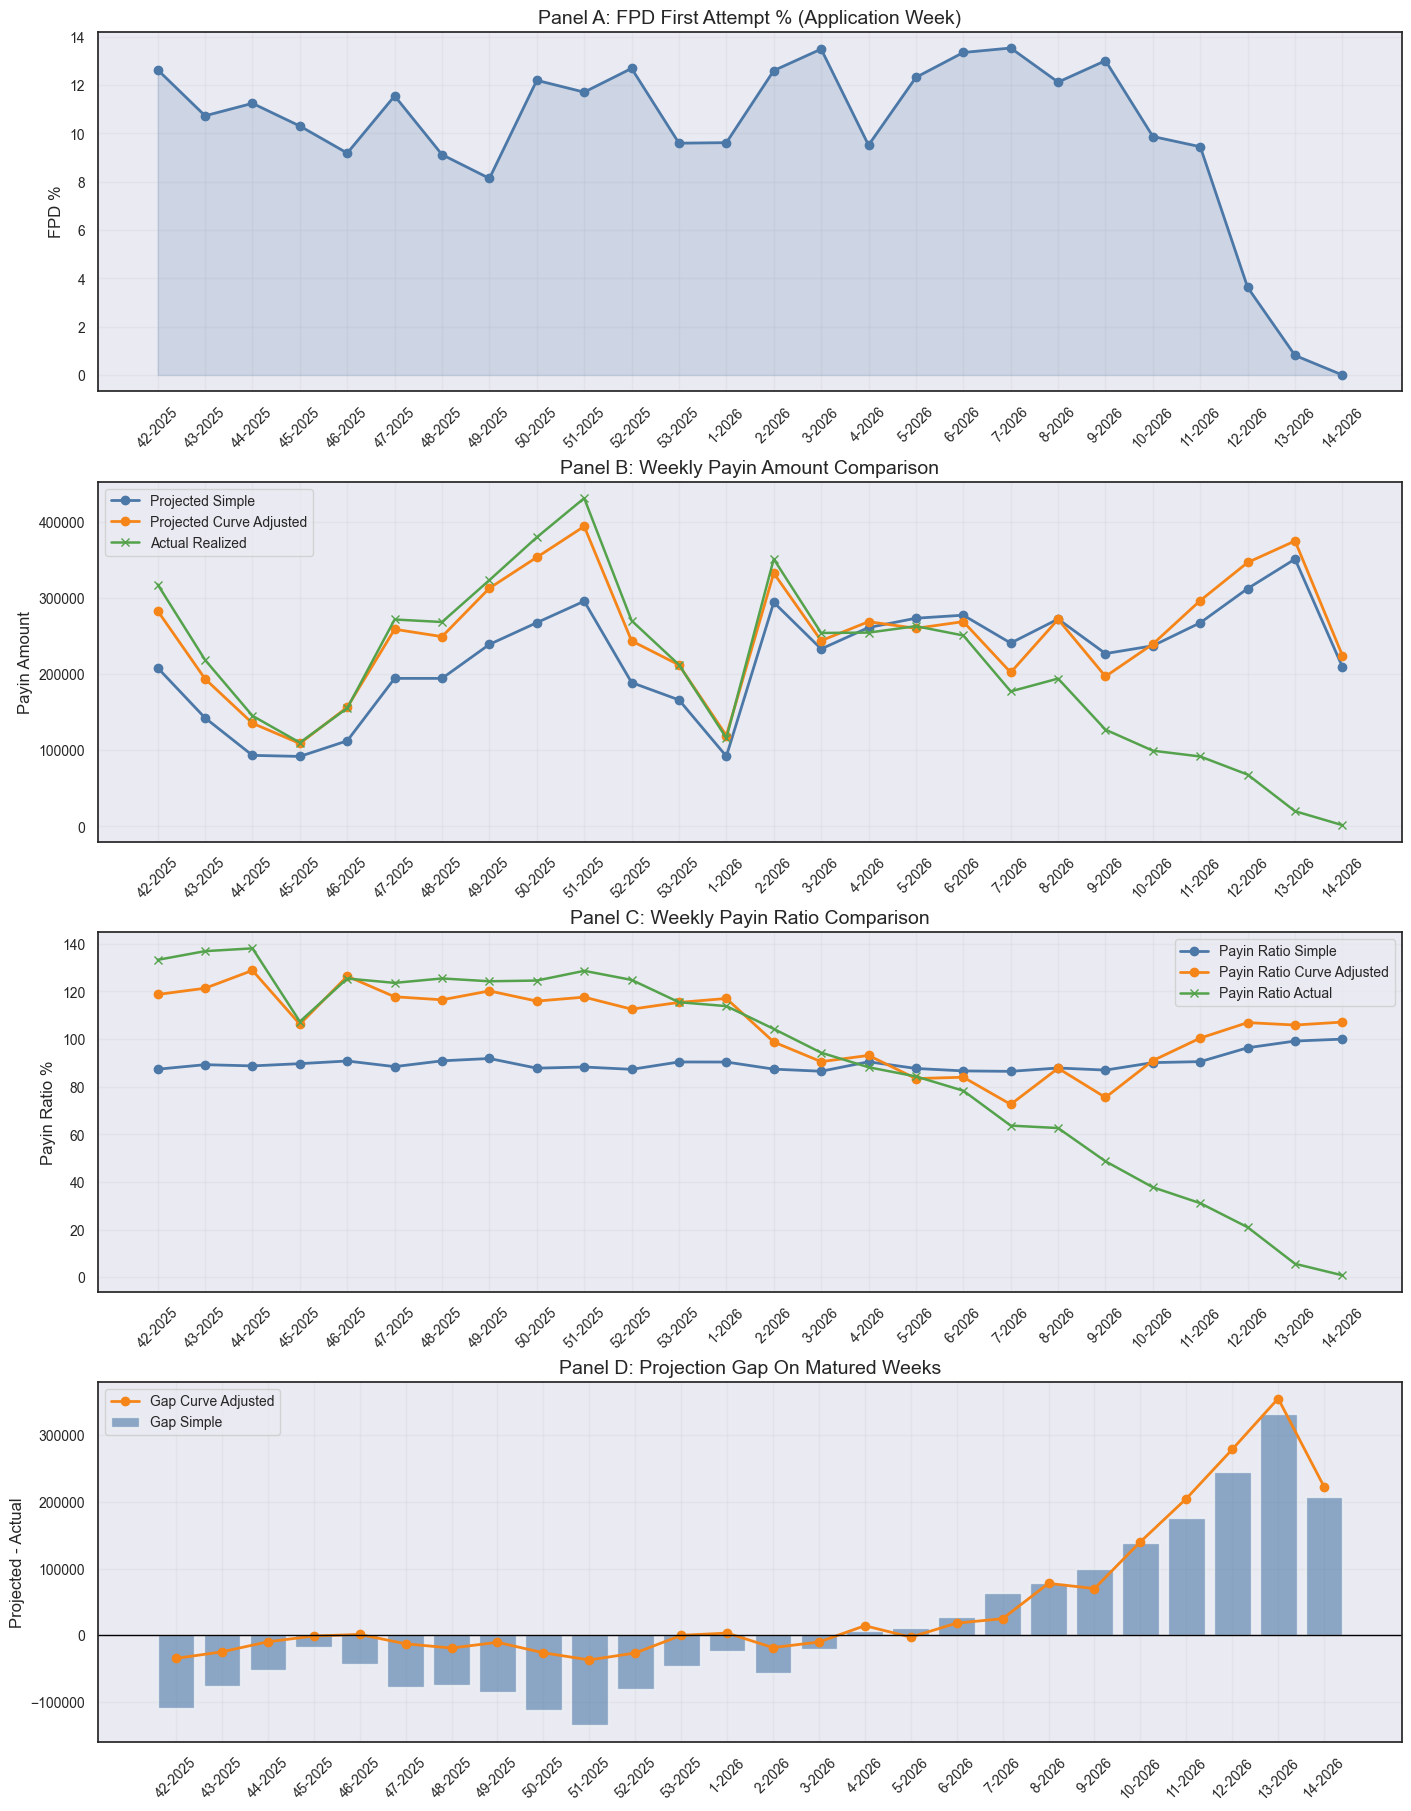

,ApplicationDateWeekYear,loan_count,originated_amount,fpd_rate,projected_payin_simple,projected_payin_curve_adjusted,actual_realized_payin,payin_ratio_simple,payin_ratio_curve_adjusted,payin_ratio_actual,projection_gap_simple,projection_gap_curve_adjusted,is_matured_week
161,2026-W03,430,269450.0,13.49,233105.58,243939.50,254099.79,86.51,90.53,94.30,-20994.21,-10160.29,True
162,2026-W04,452,288650.0,9.51,261189.93,268877.12,254561.36,90.49,93.15,88.19,6628.57,14315.76,True
163,2026-W05,479,311850.0,12.32,273438.41,260178.08,262989.49,87.68,83.43,84.33,10448.92,-2811.41,True
164,2026-W06,487,320150.0,13.35,277419.51,268937.37,250791.43,86.65,84.00,78.34,26628.08,18145.94,True
165,2026-W07,436,278500.0,13.53,240813.07,202220.29,177368.09,86.47,72.61,63.69,63444.98,24852.20,True
166,2026-W08,462,309900.0,12.12,272336.36,271967.42,194190.59,87.88,87.76,62.66,78145.77,77776.83,True
167,2026-W09,369,260950.0,13.01,227005.28,197028.20,127093.00,86.99,75.50,48.70,99912.28,69935.20,True
168,2026-W10,385,263250.0,9.87,237266.88,239527.20,99490.56,90.13,90.99,37.79,137776.32,140036.64,True
169,2026-W11,434,295350.0,9.45,267448.27,296639.04,91890.68,90.55,100.44,31.11,175557.59,204748.36,True
170,2026-W12,469,324150.0,3.62,312400.43,346640.25,68098.40,96.38,106.94,21.01,244302.03,278541.85,True


In [22]:
from util.plot_style import apply_plot_style, PRIMARY_COLOR, ACCENT_COLOR

apply_plot_style(style='white', axes_grid=False)

chart_df = weekly_projection_view.tail(26).copy()
chart_df['week_label'] = chart_df['AppWeek'].astype(int).astype(str) + '-' + chart_df['AppYear'].astype(int).astype(str)

# Weekly pay-in ratios for team review: payin_ratio = payin / originated_amount
chart_df['payin_ratio_simple'] = np.where(
    chart_df['originated_amount'] > 0,
    chart_df['projected_payin_simple'] / chart_df['originated_amount'],
    np.nan,
)
chart_df['payin_ratio_curve_adjusted'] = np.where(
    chart_df['originated_amount'] > 0,
    chart_df['projected_payin_curve_adjusted'] / chart_df['originated_amount'],
    np.nan,
)
chart_df['payin_ratio_actual'] = np.where(
    chart_df['originated_amount'] > 0,
    chart_df['actual_realized_payin'] / chart_df['originated_amount'],
    np.nan,
)

matured_chart_df = chart_df[chart_df['is_matured_week']].copy()

fig, axes = plt.subplots(4, 1, figsize=(14, 18), constrained_layout=True)

# Panel A: FPD trend.
axes[0].plot(chart_df['week_label'], chart_df['fpd_rate'] * 100, marker='o', linewidth=2, color=PRIMARY_COLOR)
axes[0].fill_between(chart_df['week_label'], chart_df['fpd_rate'] * 100, alpha=0.18, color=PRIMARY_COLOR)
axes[0].set_title('Panel A: FPD First Attempt % (Application Week)')
axes[0].set_ylabel('FPD %')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.25)

# Panel B: projected payin comparison.
axes[1].plot(chart_df['week_label'], chart_df['projected_payin_simple'], marker='o', linewidth=2, label='Projected Simple', color=PRIMARY_COLOR)
axes[1].plot(chart_df['week_label'], chart_df['projected_payin_curve_adjusted'], marker='o', linewidth=2, label='Projected Curve Adjusted', color=ACCENT_COLOR)
axes[1].plot(chart_df['week_label'], chart_df['actual_realized_payin'], marker='x', linewidth=1.8, label='Actual Realized', color='#54A24B')
axes[1].set_title('Panel B: Weekly Payin Amount Comparison')
axes[1].set_ylabel('Payin Amount')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.25)
axes[1].legend(loc='best')

# Panel C: payin ratio trend.
axes[2].plot(chart_df['week_label'], chart_df['payin_ratio_simple'] * 100, marker='o', linewidth=2, label='Payin Ratio Simple', color=PRIMARY_COLOR)
axes[2].plot(chart_df['week_label'], chart_df['payin_ratio_curve_adjusted'] * 100, marker='o', linewidth=2, label='Payin Ratio Curve Adjusted', color=ACCENT_COLOR)
axes[2].plot(chart_df['week_label'], chart_df['payin_ratio_actual'] * 100, marker='x', linewidth=1.8, label='Payin Ratio Actual', color='#54A24B')
axes[2].set_title('Panel C: Weekly Payin Ratio Comparison')
axes[2].set_ylabel('Payin Ratio %')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(alpha=0.25)
axes[2].legend(loc='best')

# Panel D: matured-week gaps.
if len(matured_chart_df) > 0:
    axes[3].bar(matured_chart_df['week_label'], matured_chart_df['projection_gap_simple'], alpha=0.6, label='Gap Simple', color=PRIMARY_COLOR)
    axes[3].plot(matured_chart_df['week_label'], matured_chart_df['projection_gap_curve_adjusted'], marker='o', linewidth=2, label='Gap Curve Adjusted', color=ACCENT_COLOR)
    axes[3].axhline(0, color='black', linewidth=1)
    axes[3].set_title('Panel D: Projection Gap On Matured Weeks')
    axes[3].set_ylabel('Projected - Actual')
    axes[3].tick_params(axis='x', rotation=45)
    axes[3].grid(alpha=0.25)
    axes[3].legend(loc='best')
else:
    axes[3].text(0.5, 0.5, 'No matured weeks available for gap chart.', ha='center', va='center')
    axes[3].set_axis_off()

plt.show()

# Panel E: compact KPI table (latest 12 weeks) with payin ratios.
kpi_cols = [
    'ApplicationDateWeekYear', 'loan_count', 'originated_amount', 'fpd_rate',
    'projected_payin_simple', 'projected_payin_curve_adjusted', 'actual_realized_payin',
    'payin_ratio_simple', 'payin_ratio_curve_adjusted', 'payin_ratio_actual',
    'projection_gap_simple', 'projection_gap_curve_adjusted', 'is_matured_week'
]
weekly_kpi_table = chart_df[kpi_cols].tail(12).copy()
weekly_kpi_table['fpd_rate'] = (weekly_kpi_table['fpd_rate'] * 100).round(2)
for c in ['payin_ratio_simple', 'payin_ratio_curve_adjusted', 'payin_ratio_actual']:
    weekly_kpi_table[c] = (weekly_kpi_table[c] * 100).round(2)
for c in ['originated_amount', 'projected_payin_simple', 'projected_payin_curve_adjusted', 'actual_realized_payin', 'projection_gap_simple', 'projection_gap_curve_adjusted']:
    weekly_kpi_table[c] = weekly_kpi_table[c].round(2)

weekly_kpi_table

In [ ]:
matured_eval = weekly_projection_view[weekly_projection_view['is_matured_week']].copy()

if len(matured_eval) > 0:
    actual = matured_eval['actual_realized_payin'].replace(0, np.nan)
    err_simple = matured_eval['projected_payin_simple'] - matured_eval['actual_realized_payin']
    err_curve = matured_eval['projected_payin_curve_adjusted'] - matured_eval['actual_realized_payin']

    validation_summary = pd.DataFrame([
        {
            'method': 'simple',
            'weekly_mae': np.nanmean(np.abs(err_simple)),
            'weekly_mape': np.nanmean(np.abs(err_simple) / actual) * 100,
            'matured_weeks': len(matured_eval),
        },
        {
            'method': 'curve_adjusted',
            'weekly_mae': np.nanmean(np.abs(err_curve)),
            'weekly_mape': np.nanmean(np.abs(err_curve) / actual) * 100,
            'matured_weeks': len(matured_eval),
        },
    ])
else:
    validation_summary = pd.DataFrame([
        {'method': 'simple', 'weekly_mae': np.nan, 'weekly_mape': np.nan, 'matured_weeks': 0},
        {'method': 'curve_adjusted', 'weekly_mae': np.nan, 'weekly_mape': np.nan, 'matured_weeks': 0},
    ])

validation_summary

---

## Forward Projection By Upcoming Due Weeks

as_of_date: 2026-04-02
projection horizon (weeks): 8
stage_c_backlog (shown separately): 6,509.18
horizon projected payin ratio: 8.25%


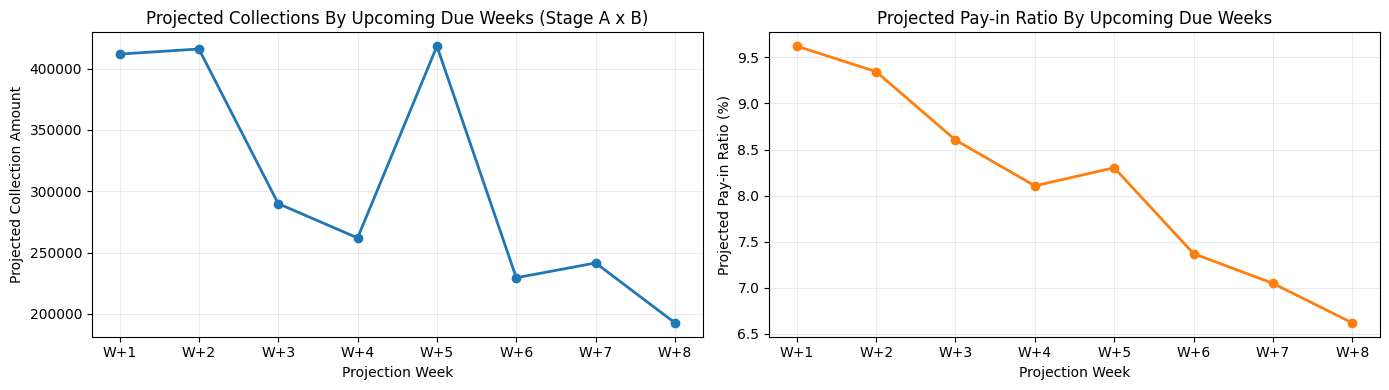

,projection_week,projected_payin_ratio,projected_ab_collection,projected_originated_amount,due_loan_count,due_installment_rows
0,W+1,0.096220,411796.947096,4279750.0,6120,6185
1,W+2,0.093454,415961.552133,4450975.0,6197,6242
2,W+3,0.086032,289853.468476,3369150.0,4778,4790
3,W+4,0.081056,261913.531434,3231250.0,4563,4570
4,W+5,0.083020,418256.616524,5038000.0,7172,7181
5,W+6,0.073702,229437.074698,3113050.0,4422,4426
6,W+7,0.070471,241501.605850,3426950.0,4827,4834
7,W+8,0.066180,192639.542678,2910850.0,4119,4122


In [21]:
# Revised forward projection block (fixes as_of_date anchor and highlights pay-in ratio)
projection_weeks_ahead = 8

# Use run date by default; set explicit date for reproducible snapshots.
as_of_date_override = None  # Example: pd.Timestamp('2026-03-31')
as_of_date = pd.Timestamp(as_of_date_override).normalize() if as_of_date_override is not None else pd.Timestamp.today().normalize()

forward_seq = seq_base[
    ['LoanID', 'PortFolioID', 'InstallmentNumber', 'InstallDueDate', 'OriginatedAmount', 'stage_b_pred_ratio']
].merge(
    loan_survival_df,
    on=['LoanID', 'PortFolioID', 'InstallmentNumber'],
    how='left'
)
forward_seq['survival_prob'] = forward_seq['survival_prob'].fillna(1.0)

forward_seq['InstallDueDate'] = pd.to_datetime(forward_seq['InstallDueDate'], errors='coerce')
forward_seq = forward_seq.dropna(subset=['InstallDueDate']).copy()

forward_seq['week_offset'] = ((forward_seq['InstallDueDate'].dt.normalize() - as_of_date).dt.days // 7) + 1
forward_seq = forward_seq[(forward_seq['week_offset'] >= 1) & (forward_seq['week_offset'] <= projection_weeks_ahead)].copy()

# Guardrail for presentation: expected collections should not be negative.
forward_seq['projected_ab_collection'] = (
    forward_seq['survival_prob'] *
    forward_seq['stage_b_pred_ratio'] *
    forward_seq['OriginatedAmount']
).clip(lower=0.0)

upcoming_projection = (
    forward_seq.groupby('week_offset', as_index=False)
    .agg(
        projected_ab_collection=('projected_ab_collection', 'sum'),
        projected_originated_amount=('OriginatedAmount', 'sum'),
        due_installment_rows=('LoanID', 'size'),
        due_loan_count=('LoanID', 'nunique')
    )
    .sort_values('week_offset')
)

if upcoming_projection.empty:
    upcoming_projection = pd.DataFrame({
        'week_offset': np.arange(1, projection_weeks_ahead + 1),
        'projected_ab_collection': 0.0,
        'projected_originated_amount': 0.0,
        'due_installment_rows': 0,
        'due_loan_count': 0,
    })

upcoming_projection['projection_week'] = 'W+' + upcoming_projection['week_offset'].astype(int).astype(str)
upcoming_projection['projected_payin_ratio'] = np.where(
    upcoming_projection['projected_originated_amount'] > 0,
    upcoming_projection['projected_ab_collection'] / upcoming_projection['projected_originated_amount'],
    0.0,
)

stage_c_backlog = float(stage_c_projection['expected_collection'].sum()) if 'stage_c_projection' in globals() else 0.0
horizon_originated = float(upcoming_projection['projected_originated_amount'].sum())
horizon_collection = float(upcoming_projection['projected_ab_collection'].sum())
horizon_payin_ratio = (horizon_collection / horizon_originated) if horizon_originated > 0 else 0.0

print('as_of_date:', as_of_date.date())
print('projection horizon (weeks):', projection_weeks_ahead)
print('stage_c_backlog (shown separately):', f'{stage_c_backlog:,.2f}')
print('horizon projected payin ratio:', f'{horizon_payin_ratio:.2%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(upcoming_projection['projection_week'], upcoming_projection['projected_ab_collection'], marker='o', linewidth=2)
axes[0].set_title('Projected Collections By Upcoming Due Weeks (Stage A x B)')
axes[0].set_ylabel('Projected Collection Amount')
axes[0].set_xlabel('Projection Week')
axes[0].grid(alpha=0.25)

axes[1].plot(upcoming_projection['projection_week'], upcoming_projection['projected_payin_ratio'] * 100.0, marker='o', linewidth=2, color='tab:orange')
axes[1].set_title('Projected Pay-in Ratio By Upcoming Due Weeks')
axes[1].set_ylabel('Projected Pay-in Ratio (%)')
axes[1].set_xlabel('Projection Week')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

upcoming_projection[
    ['projection_week', 'projected_payin_ratio', 'projected_ab_collection', 'projected_originated_amount', 'due_loan_count', 'due_installment_rows']
]